In [2]:

import numpy as np
import matplotlib.pyplot as plt 
from matplotlib.colors import ListedColormap, BoundaryNorm
import time
from configurations.data import make_data_paths , sanitize
import pandas as pd

# from spin_sampler import Sampler , define_hopfield_model , initialize_spins
from configurations import load_data, make_params_dict, set_font_sizes, create_fig , apply_general_styles, save_fig
from configurations.plots import FONTSIZES
from configurations.data import download_cluster_data

apply_general_styles()

# N scaling of BID/N vs T

In [10]:
# Get data from cluster --> later

In [28]:
# Parse arguments
a_min = 1e-3
a_max = 0.3
z_threshold = 3
kl_perc = 80 

# Parameters fixed
N_samples = 10000
dt_samples = 1
burnin = 800
alpha = 0.04
h = 0.9
rnd_ord = True
mode = 'single_chain'

# Parameters Lists
temps = np.linspace(0.4,1.6,25)
temps = np.concatenate((temps, [0.56,1.19, 1.21]))
temps = np.sort(temps)
temps = temps[temps>=1.1]
# temps = temps[temps<=1.5]
Ns = np.logspace(9,15,7,base=2).astype(int)[1:-1]

# Parameters to save
names_variable = ['T','N']
name_fixed = ['N_samples','dt_samples','burnin','alpha','h','rnd_ord','mode','a_min','a_max','z_threshold','kl_perc']


results = {
    N: {'av': [],'st':[] }  for N in Ns
    }

data = []
for N in Ns:
    for T in temps:
        params = make_params_dict(name_fixed,names_variable)
        # print('-----------\n',f'Loading N={N}, T={T}...')
        dic = load_data('par',experiment_name= 'scaling_exponents_filtered', params=params,base_dir='..\\data',show=False)
        # print(dic['sigmas'].shape)
        # bid = dic['bid_pars'][:,0]
        bid = dic['sigmas']**2 * N
        data.append([N,T,bid.mean(),bid.std()])
        results[N]['av'].append(bid.mean())
        results[N]['st'].append(bid.std())
    results[N]['av'] = np.array(results[N]['av'])
    results[N]['st'] = np.array(results[N]['st'])
data = np.array(data)
print(data.shape)

np.savetxt('../data/fss/var.dat',data)

(65, 4)


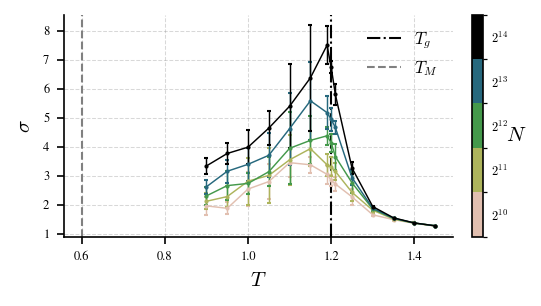

In [9]:
# Settings

cmap = 'gist_earth_r'
colors = plt.get_cmap(cmap)(np.linspace(0.1,1,len(Ns)))
set_font_sizes(conf='tight')
Nlbs = [rf'$2^{{{int(np.log2(N))}}}$' for N in Ns]


# Plotting
fig , axes = create_fig(h=0.55,w=1.0)
ax = axes

ax.axvline(1.2,color='black',ls='-.',lw=1,label=r'$T_g$')
ax.axvline(0.6,color='gray',ls='--',lw=1,label=r'$T_M$')
for i , N in enumerate(Ns):
    # ax.plot(temps, results[N]['av'], label=f'N={N}', marker='.',markersize=2,lw=0.7,color=colors[i])
    ax.errorbar(temps, results[N]['av'], yerr=results[N]['st'], marker='.',markersize=2,lw=0.7, capsize=1,color=colors[i])

ax.grid(True, which='both', ls='--', lw=0.5,color='gray', alpha=0.3)
ax.set_xlabel(r'$T$')
# ax.set_ylabel(r'$BID / N$')
ax.set_ylabel(r'$\sigma$')
ax.legend(frameon=False,fontsize=FONTSIZES['s'])

# Create discrete colormap and colorbar with discrete colors
cmap = ListedColormap(colors)
bounds = np.arange(len(Ns) + 1)
norm = BoundaryNorm(bounds, cmap.N)

cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap=cmap,norm=norm),
    ax=ax, orientation='vertical')#,pad=0.05)

cbar.set_label(r'$N$', rotation=0)#, labelpad=10)
# Ticks and labels
cbar.set_ticks(ticks=(np.arange(len(Ns)) + 0.5), labels= Nlbs)
cbar.ax.tick_params(length=0)  # Optional: remove tick lines for clarity


names = ['N_samples','alpha','h','mode','a_min','a_max','z_threshold','kl_perc']
params = make_params_dict(names)
# save_fig(fig, 'BID_vs_T_scaling',params=params)

# Graph collapse


In [32]:
# Parse arguments
a_min = 1e-3
a_max = 0.3
z_threshold = 3
kl_perc = 80 

# Parameters fixed
N_samples = 10000
dt_samples = 1
burnin = 800
alpha = 0.04
h = 0.9
rnd_ord = True
mode = 'single_chain'

# Parameters Lists
temps = np.linspace(0.4,1.6,25)
temps = np.concatenate((temps, [0.56,1.19, 1.21]))
temps = np.sort(temps)
temps = temps[temps>=0.8]
temps = temps[temps<=1.4]
Ns = np.logspace(9,15,7,base=2).astype(int)[1:-1]

# Parameters to save
names_variable = ['T','N']
name_fixed = ['N_samples','dt_samples','burnin','alpha','h','rnd_ord','mode','a_min','a_max','z_threshold','kl_perc']


results = {
    N: {'av': [],'st':[] }  for N in Ns
    }

for N in Ns:
    for T in temps:
        params = make_params_dict(name_fixed,names_variable)
        # print('-----------\n',f'Loading N={N}, T={T}...')
        dic = load_data('par',experiment_name= 'scaling_exponents_filtered', params=params,base_dir='..\\data',show=False)
        bid = dic['bid_pars'][:,0]
        # bid = dic['sigmas']**2 * N
        
        results[N]['av'].append(bid.mean())
        results[N]['st'].append(bid.std())
    results[N]['av'] = np.array(results[N]['av'])
    results[N]['st'] = np.array(results[N]['st'])

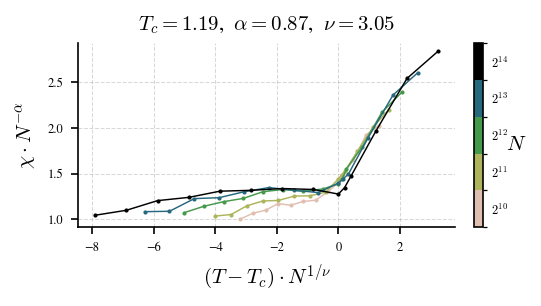

In [49]:
# Settings
# Retulst BID
# Tc = 1.218016505241394
# c1 = 0.34914830327033997
# c2 = -0.9545260667800903
# # Results CHI
# Tc = 1.2179301977157593
Tc = 1.19
c1 = 0.41859498620033264
c2 = -0.2485182136297226
# alpha = -c2
# nu = 1/c1
nu = 3.05
alpha = 0.87


cmap = 'gist_earth_r'
colors = plt.get_cmap(cmap)(np.linspace(0.1,1,len(Ns)))
set_font_sizes(conf='tight')
Nlbs = [rf'$2^{{{int(np.log2(N))}}}$' for N in Ns]


# Plotting
fig , axes = create_fig(h=0.55,w=1.0)
ax = axes

for i , N in enumerate(Ns):
    bid = results[N]['av']
    x = bid*N**-alpha
    t = (temps - Tc)/Tc *N**(1/nu)
    ax.plot(t, x, marker='.',markersize=2,lw=0.7,color=colors[i])
    errx = results[N]['st']*N**-alpha
    # ax.errorbar(t, x,yerr=errx, marker='.',markersize=2,lw=0.7, capsize=1,color=colors[i])

ax.grid(True, which='both', ls='--', lw=0.5,color='gray', alpha=0.3)
ax.set_xlabel(r'$(T-T_c) \cdot N^{1/\nu}$')
ax.set_ylabel(r'$\chi \cdot N^{-\alpha}$')

# ax.legend(frameon=False,fontsize=FONTSIZES['s'])

# Create discrete colormap and colorbar with discrete colors
cmap = ListedColormap(colors)
bounds = np.arange(len(Ns) + 1)
norm = BoundaryNorm(bounds, cmap.N)

cbar = fig.colorbar(
    plt.cm.ScalarMappable(cmap=cmap,norm=norm),
    ax=ax, orientation='vertical')#,pad=0.05)

cbar.set_label(r'$N$', rotation=0)#, labelpad=10)
# Ticks and labels
cbar.set_ticks(ticks=(np.arange(len(Ns)) + 0.5), labels= Nlbs)
cbar.ax.tick_params(length=0)  # Optional: remove tick lines for clarity

ax.set_title(rf'$T_c = {Tc:.3}$,  $\alpha={alpha:.3}$,  $\nu={nu:.3}$')

# ax.set_xlim(-5,5)
# ax.set_ylim(0.5,4)
names = ['N_samples','alpha','h','mode','a_min','a_max','z_threshold','kl_perc']
params = make_params_dict(names)
# save_fig(fig, 'bid_vs_T_scaling',params=params)

# New data

In [39]:
N_samples = 10000
alpha = 0.04
burnin = 1500
h = 0

path = f'../data/fss/N_samples{N_samples}_alpha{alpha}_burnin{burnin}_h{h}/'

Ns = [4096,8192,16384,32768]
temps = np.linspace(1.0,1.4,21)
# N = 4096
# T = 1.0

names = ['N','T','m','q','BID','th1','logKL','Nit','mean_x','chi']
data = {name: [] for name in names}

for N in Ns:
    for T in temps:
        # print(f'Loading N={N}, T={T}...')
        filename = path + f'summary_N{N}_T{sanitize(T)}.txt'
        # Try to load file, if not found, skip
        try:
            x = np.loadtxt(filename)
            n_runs = x.shape[0]
            for i, name in enumerate(names[2:]):
                data[name] += x[:,i].tolist()
            data['N'] += [N]*n_runs
            data['T'] += [T]*n_runs
        except FileNotFoundError:
            print(f'File not found with N={N} and T={T}, skipping...')

data = pd.DataFrame(data)
columns_to_keep = ['N','T','BID','logKL','chi']
data = data[columns_to_keep]
data.info(memory_usage='deep')

# Filter out runs with inf KL
data = data[np.isfinite(data['logKL'])]

kl_threshold = -3
data = data[data['logKL'] <= kl_threshold]
data.info(memory_usage='deep')



File not found with N=4096 and T=1.04, skipping...
<class 'pandas.DataFrame'>
RangeIndex: 1526 entries, 0 to 1525
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   N       1526 non-null   int64  
 1   T       1526 non-null   float64
 2   BID     1524 non-null   float64
 3   logKL   1525 non-null   float64
 4   chi     1526 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 59.7 KB
<class 'pandas.DataFrame'>
Index: 1479 entries, 0 to 1525
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   N       1479 non-null   int64  
 1   T       1479 non-null   float64
 2   BID     1479 non-null   float64
 3   logKL   1479 non-null   float64
 4   chi     1479 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 69.3 KB


(array([ 70., 201., 115.,  13.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   1.,  15.,   1.,   0.,   0.,   0.,   0.,
          1.,   0.,   0.,   0.,   0.,   0.,   0.,   1.]),
 array([-5.69049294, -5.34390571, -4.99731849, -4.65073127, -4.30414404,
        -3.95755682, -3.6109696 , -3.26438237, -2.91779515, -2.57120793,
        -2.2246207 , -1.87803348, -1.53144626, -1.18485903, -0.83827181,
        -0.49168459, -0.14509736,  0.20148986,  0.54807708,  0.89466431,
         1.24125153,  1.58783875,  1.93442598,  2.2810132 ,  2.62760042,
         2.97418765,  3.32077487,  3.66736209,  4.01394932,  4.36053654,
         4.70712376]),
 <BarContainer object of 30 artists>)

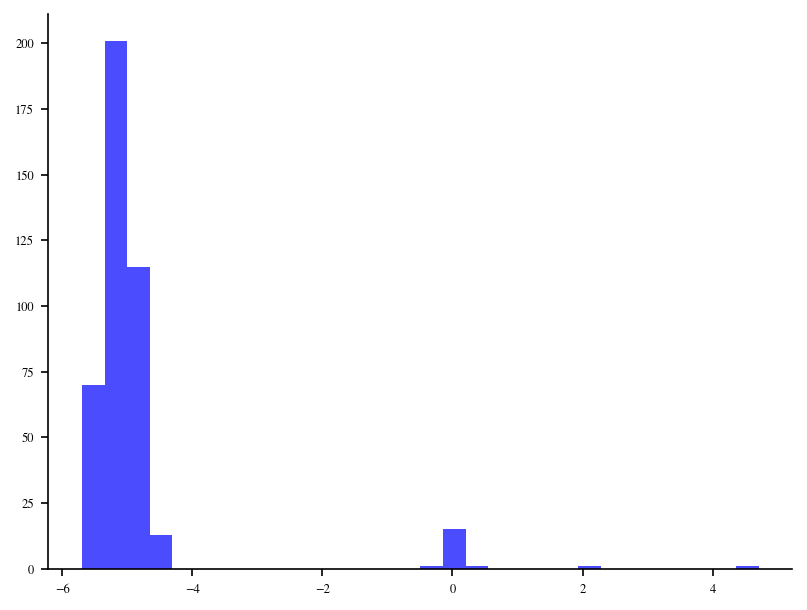

In [37]:
logkls = data['logKL'][data['N'] == Ns[1]].values
plt.hist(logkls, bins=30, color='blue', alpha=0.7)

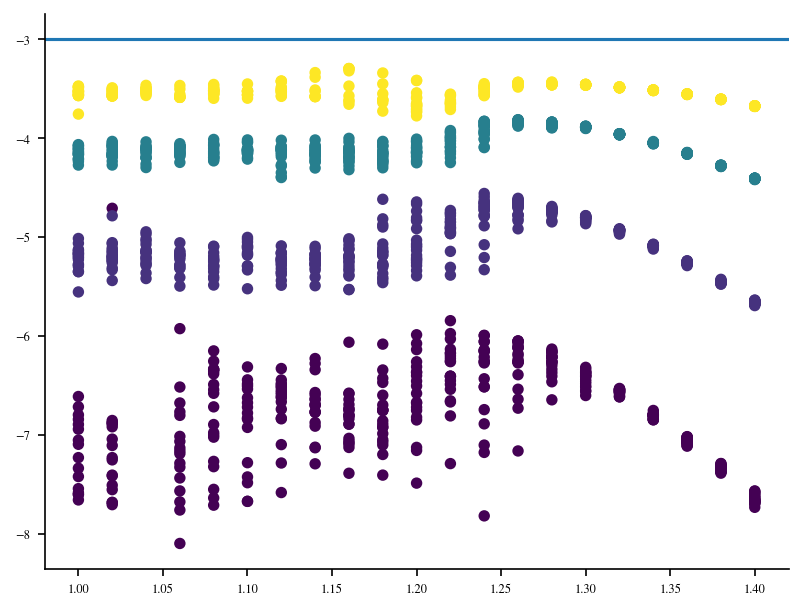

In [40]:
plt.scatter(data['T'],data['logKL'],c=data['N'],cmap='viridis',s=20)
plt.axhline(-3)

In [41]:
# For all configurations with same N and T, compute mean and std of the other variables and save in new df
grouped = data.groupby(['N','T']).agg(['mean','std']).reset_index()
grouped.columns = ['_'.join(col).strip('_') for col in grouped.columns.values]
grouped.info(memory_usage='deep')


<class 'pandas.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   N           83 non-null     int64  
 1   T           83 non-null     float64
 2   BID_mean    83 non-null     float64
 3   BID_std     83 non-null     float64
 4   logKL_mean  83 non-null     float64
 5   logKL_std   83 non-null     float64
 6   chi_mean    83 non-null     float64
 7   chi_std     83 non-null     float64
dtypes: float64(7), int64(1)
memory usage: 5.3 KB


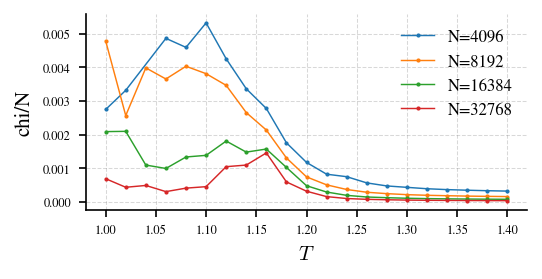

In [49]:

var = 'chi'
set_font_sizes(conf='tight')
fig , axes = create_fig()

for N in Ns:
    subset = grouped[grouped['N'] == N]
    ax = axes
    ax.plot(subset['T'], subset[f'{var}_mean'], marker='.',markersize=2,lw=0.7,label=f'N={N}')
    # ax.errorbar(subset['T'], subset[f'{var}_mean'], yerr=subset[f'{var}_std'], marker='.',markersize=2,lw=0.7, capsize=1,label=f'N={N}')
    ax.grid(True, which='both', ls='--', lw=0.5,color='gray', alpha=0.3)
    ax.set_xlabel(r'$T$')
    ax.set_ylabel(var+'/N')
    ax.legend(frameon=False,fontsize=FONTSIZES['s'])